<a href="https://colab.research.google.com/github/ftzanha00-max/STUDENT-PERFORMANCE-ANALYSIS-/blob/main/Sms%20or%20spam%20detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam.csv


In [ ]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')

print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None


In [ ]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [ ]:
print(df.shape)

(5572, 5)


Model Evaluation
R2 Score : 0.7914229515666577
MAE       : 0.06303964468350406
RMSE      : 0.1558359588615663


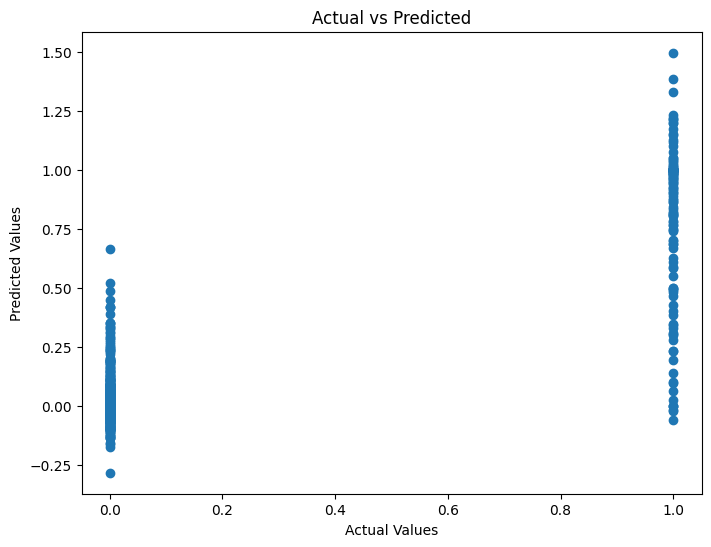

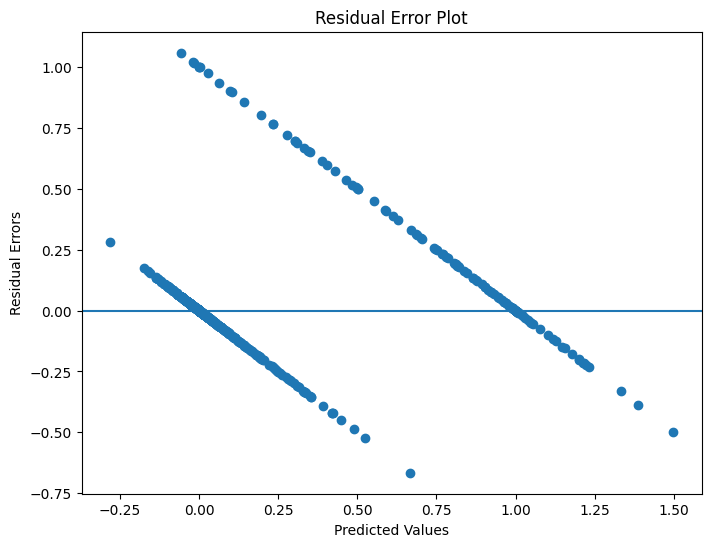

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("spam.csv", encoding='latin-1')

# Keep only useful columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Convert labels to numbers
# ham = 0, spam = 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Features and target
X = df['message']
y = df['label']

# Convert text to numerical features
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print metrics
print("Model Evaluation")
print("R2 Score :", r2)
print("MAE       :", mae)
print("RMSE      :", rmse)

# ---------------- GRAPH 1 ----------------
# Actual vs Predicted

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

# ---------------- GRAPH 2 ----------------
# Residual Error Plot

errors = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, errors)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")
plt.title("Residual Error Plot")

plt.show()